# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from category_encoders import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras, obtener_cols_flag
from src.config import clean_data_file, reports_folder
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 35309
Data columns (total 77 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 32242 non-null  float64       
 1   CurrentDebt                            32242 non-null  float64       
 2   LongTermDebt                           32242 non-null  float64       
 3   TotalDebt                              32242 non-null  float64       
 4   StockholdersEquity                     32242 non-null  float64       
 5   TotalAssets                            32242 non-null  float64       
 6   CurrentAssets                          32242 non-null  float64       
 7   CurrentLiabilities                     32242 non-null  float64       
 8   TotalNoncurrentLiabilities             32242 non-null  float64       
 9   TotalLiabilities                       32242 non-null  float64    

## Feature Engineering

In [ ]:
# Celda reservada para probar la creación de variables en la fase de modelado.



## Modelo de ensamblado de árboles RandomForest

In [4]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras()

# Columnas flag: las quito por su baja relevancia
cols_flag = obtener_cols_flag(df)

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
    'AverageDailyVolume_Lag1_YoY_Yeo',
    'FreeCashFlow_TTM_QoQ',
    'CapitalExpenditure_TTM_QoQ',
    'AverageDailyVolume_Lag1_Acceleration',
    'CapitalExpenditure_TTM_YoY',
    'CurrentRatio_Log1p',
    'Industry'
]

predictores_a_eliminar = cols_financieras + cols_flag + variables_no_significativas + [
    # Variable objetivo
    'MonthlyExcessReturn_Quantile',
    'Target_Top_Quintile',

    # Variables de volumen y precios crudos: 
    # No tiene sentido utilizarlas habiendo multiples tickers
    'Open',
    'Close',    
    'AverageDailyVolume_Lag1',

    # Otros (se matiene Date para aplicar en el ranking)
    'Ticker',
    'FinancialsSource'
    ]

# Se define la variable objetivo (categórica)
label = 'Target_Top_Quintile'

# Se separan los datos pasados de los del mes actual
# X_train / y_train: Todos los meses históricos completamente cerrados
# X_live / _ : El mes actual en curso (y_test se ignora porque es inválido)
X_train, X_live, y_train, _ = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Columnas numéricas: 
columnas_num = X_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in columnas_num if col != 'Date']

# Variables categóricas:
columnas_cat = X_train.select_dtypes(exclude=np.number).columns.tolist()
categorical_cols = [col for col in columnas_cat if col != 'Date']

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_cols),
    ('cat', OneHotEncoder(), categorical_cols)
])

# Reemplazo de RandomForestRegressor por RandomForestClassifier
pipe = Pipeline([
    ('ranker', CrossSectionalRanker(date_col='Date')), # Rankea y elimina la columna 'Date'
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=400,
        max_depth=3,
        min_samples_leaf=50,
        min_samples_split= 100,
        max_samples= 0.5,
        max_features=0.1,
        class_weight='balanced'        
        ))
])

print("Entrenando el modelo clasificador con datos históricos completos...")
pipe.fit(X_train, y_train)

# Predicciones sobre el set de entrenamiento
y_train_pred = pipe.predict(X_train)

# Calcular la métrica de Precisión
precision_entrenamiento = precision_score(y_train, y_train_pred)
print(f"Entrenamiento finalizado. Precision en histórico: {precision_entrenamiento:.4f}")

Entrenando el modelo clasificador con datos históricos completos...
Entrenamiento finalizado. Precision en histórico: 0.2637


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X_train, 
    y=y_train, 
    cv=tscv,         
    scoring='precision',
    n_jobs=-1        
)

print(f"Precision promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

Precision promedio Time Series CV: 0.2561 ± 0.0143


In [6]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(25)

,feature,importance
25,num__Variance_Yeo,0.146974
21,num__ProfitMargins_Yeo,0.070729
28,num__EarningsYield_Yeo,0.068781
20,num__OperatingMargins_Yeo,0.067929
10,num__ShortTermBeta,0.052445
12,num__MarketCap_Log1p,0.050448
19,num__EBITDA_TTM_YoY_Yeo,0.049170
24,num__EnterpriseValue_Yeo,0.042916
0,num__YearsSinceAdded,0.034822
22,num__ReturnOnAssets_Yeo,0.033751


In [7]:
# Variables menos significativas
feature_importance_df.tail(20)

,feature,importance
5,num__FreeCashFlow_TTM_YoY,0.018289
27,num__BookToMarket_Yeo,0.016449
13,num__MonthlyReturn_Yeo,0.014599
8,num__FreeCashFlow_TTM_Acceleration,0.013599
15,num__FcfToEbitda_Yeo,0.008757
11,num__DebtToEquity_Log1p,0.007263
26,num__CapExToRevenue_Log1p,0.006127
17,num__AverageDailyVolume_Lag1_QoQ_Yeo,0.005354
9,num__CapitalExpenditure_TTM_Acceleration,0.004951
30,cat__Sector_2,0.004122


In [8]:
# Visualizar distribución de features
X_train.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,31757,2023-09-16 10:49:03.527411200,2021-01-01 00:00:00,2022-05-01 00:00:00,2023-09-01 00:00:00,2025-02-01 00:00:00,2026-06-01 00:00:00,NaN
YearsSinceAdded,31757.0,14.449381,0.0,0.0,5.0,23.0,69.0,19.971606
EbitdaYield,31757.0,0.0803,-1.293643,0.044376,0.067728,0.103129,1.390862,0.104137
RevenueYield,31757.0,0.773041,-2.0,0.232162,0.47653,0.955228,7.5,0.89091
AssetToMarket,31757.0,1.463499,0.001536,0.496607,0.926024,1.777015,15.416756,1.591274
NetDebtToEbitda,31757.0,2.479281,-16.248426,0.669356,1.992038,3.77779,20.958458,3.745739
FreeCashFlow_TTM_YoY,31757.0,0.2469,-4.415398,-0.250621,0.03,0.413124,4.556598,1.290341
TotalRevenue_TTM_Acceleration,31757.0,-0.064818,-1.363345,-0.097848,-0.03581,0.006844,1.30766,0.178488
EBITDA_TTM_Acceleration,31757.0,-0.144288,-3.430456,-0.226611,-0.050796,0.062743,3.327471,0.666338
FreeCashFlow_TTM_Acceleration,31757.0,-0.221325,-8.650107,-0.395521,-0.029444,0.225801,8.313115,2.102352


## Aplicación del modelo

In [14]:
# Predicciones de la clase (Quintil 1 al 5)
y_pred_class = pipe.predict(X_live)

# Predicciones de probabilidad para desempatar y rankear
y_pred_proba = pipe.predict_proba(X_live)

# Extraer el modelo final del pipeline para conocer el orden de las clases
rf_model = pipe.named_steps['model']

# Identificar el índice de la columna que contiene la probabilidad de la clase 1 (Top Quintile)
idx_top = list(rf_model.classes_).index(1)
proba_top = y_pred_proba[:, idx_top]

# Recuperar los Tickers correspondientes a X_live
tickers_test = df.loc[X_live.index, 'Ticker']

# Construir el DataFrame de resultados
resultados_agrupados = pd.DataFrame({
    'Ticker': tickers_test.values,
    'Predicted_Class': y_pred_class,
    'Probability_Top': proba_top
})

# Generar la señal
resultados_agrupados['Signal'] = np.where(
    resultados_agrupados['Predicted_Class'] == 1, 'Top_Quantile', 'Neutral'
)

# Ordenar resultados por la probabilidad de ser Top Quintil
resultados_agrupados = resultados_agrupados.sort_values(by='Probability_Top', ascending=False)

print(resultados_agrupados.head(10).to_string(index=False))

Ticker  Predicted_Class  Probability_Top       Signal
   XRX                1         0.641052 Top_Quantile
  JELD                1         0.627755 Top_Quantile
   ADV                1         0.625855 Top_Quantile
  TROX                1         0.622394 Top_Quantile
  CPHI                1         0.617571 Top_Quantile
  CNDT                1         0.614571 Top_Quantile
    MU                1         0.610647 Top_Quantile
    GO                1         0.609235 Top_Quantile
   CNC                1         0.605787 Top_Quantile
   WDC                1         0.603304 Top_Quantile


In [15]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

# Crear carpeta si no existe y nombrar el archivo con la fecha
reports_folder.mkdir(parents=True, exist_ok=True)
nombre_archivo = f"{year}_{mes}_{dia}.csv"
ruta_completa = reports_folder / nombre_archivo

df_reporte.to_csv(ruta_completa, index=False)
print(f'Reporte exportado en la carpeta de datos.')
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Predicted_Class,Probability_Top,Signal,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,...,OperatingMargins_Yeo,ProfitMargins_Yeo,ReturnOnAssets_Yeo,ReturnOnEquity_Yeo,EnterpriseValue_Yeo,Variance_Yeo,CapExToRevenue_Log1p,BookToMarket_Yeo,EarningsYield_Yeo,Target_Top_Quintile
0,XRX,1,0.641052,Top_Quantile,585.000000,165.000000,4281.00000,4446.000000,513.00000,9902.00000,...,-0.933113,-1.336530,-1.673195,-0.272448,-0.402677,3.130346,0.012338,1.771297,-5.000000,0
1,JELD,1,0.627755,Top_Quantile,50.361000,19.526000,1189.43600,1406.767000,12.18100,2077.26800,...,-1.013091,-1.425931,-2.673436,-1.445022,-0.440589,3.127727,0.037322,-1.060677,-5.000000,0
2,ADV,1,0.625855,Top_Quantile,143.870000,25.865000,1520.79000,1546.655000,478.02800,2564.85000,...,-0.861754,-0.987363,-1.587097,-0.111452,-0.433384,3.161543,0.013612,1.180120,-3.063720,0
3,TROX,1,0.622394,Top_Quantile,126.000000,172.000000,3124.00000,3464.000000,1289.00000,6057.00000,...,-1.042915,-1.414222,-1.430416,-0.092357,-0.401753,2.968179,0.097176,1.761147,-3.164599,0
4,CPHI,1,0.617571,Top_Quantile,0.168474,3.692422,0.16368,3.856102,37.02419,45.14379,...,-3.595023,-3.308405,-1.449664,-0.057704,-0.471860,3.067518,0.020997,2.981116,-3.637629,1


## Explicabilidad del Modelo (SHAP)

In [19]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'XRX'

--- Explicación de la probabilidad de ser Quintil 5 para: XRX ---


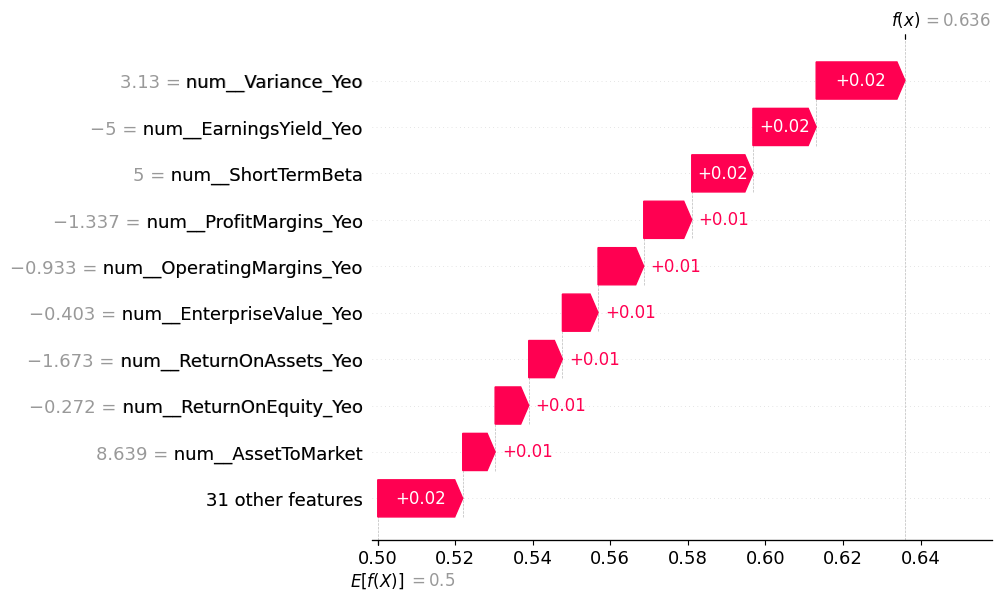

In [20]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_live)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_live.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test.values == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP
    shap_values = explainer(X_ticker_eval)
    
    # Seleccionar la explicación específica para la clase 1 (Top Quintile)
    idx_top = list(rf_model.classes_).index(1)
    shap_values_q5 = shap_values[..., idx_top]
    
    print(f"--- Explicación de la probabilidad de ser Quintil 5 para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada
    shap.plots.waterfall(shap_values_q5[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [18]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest Classifier"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el clasificador
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestClassifier(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [400],
        'rf__max_depth': [3],
        'rf__min_samples_leaf': [40],
        'rf__min_samples_split': [80],
        'rf__max_samples': [0.5],
        'rf__max_features': [0.1]
    }

    # Configurar el GridSearchCV con la métrica correcta
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='precision',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X_train, y_train)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)